In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [66]:
#Hit Song 
#(df_combined[Peak Position] <= 10) & (df_combined[Weeks on Chart] >= 10)

In [2]:
df_songs = pd.read_csv("./data/Hot Stuff.csv")
df_songs.head(5)

,index,url,WeekID,Week Position,Song,Performer,SongID,Instance,Previous Week Position,Peak Position,Weeks on Chart
0,0,http://www.billboard.com/charts/hot-100/1965-0...,7/17/1965,34,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,45.0,34,4
1,1,http://www.billboard.com/charts/hot-100/1965-0...,7/24/1965,22,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,34.0,22,5
2,2,http://www.billboard.com/charts/hot-100/1965-0...,7/31/1965,14,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,22.0,14,6
3,3,http://www.billboard.com/charts/hot-100/1965-0...,8/7/1965,10,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,14.0,10,7
4,4,http://www.billboard.com/charts/hot-100/1965-0...,8/14/1965,8,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,10.0,8,8


In [31]:
df_features = pd.read_csv("./data/Hot 100 Audio Features.csv")
df_features.head(2)

,index,SongID,Performer,Song,spotify_genre,spotify_track_id,spotify_track_preview_url,spotify_track_duration_ms,spotify_track_explicit,spotify_track_album,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity
0,0,-twistin'-White Silver SandsBill Black's Combo,Bill Black's Combo,-twistin'-White Silver Sands,[],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,¿Dònde Està Santa Claus? (Where Is Santa Claus...,Augie Rios,¿Dònde Està Santa Claus? (Where Is Santa Claus?),['novelty'],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df_combined = pd.merge(df_songs, df_features, on='SongID')
df_combined.head(2)

,index_x,url,WeekID,Week Position,Song_x,Performer_x,SongID,Instance,Previous Week Position,Peak Position,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity
0,0,http://www.billboard.com/charts/hot-100/1965-0...,7/17/1965,34,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,45.0,34,...,-15.044,1.0,0.0298,0.61,0.000077,0.1,0.568,82.331,3.0,21.0
1,1,http://www.billboard.com/charts/hot-100/1965-0...,7/24/1965,22,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,34.0,22,...,-15.044,1.0,0.0298,0.61,0.000077,0.1,0.568,82.331,3.0,21.0


In [35]:
df_combined.columns

Index(['index_x', 'url', 'WeekID', 'Week Position', 'Song_x', 'Performer_x',
       'SongID', 'Instance', 'Previous Week Position', 'Peak Position',
       'Weeks on Chart', 'index_y', 'Performer_y', 'Song_y', 'spotify_genre',
       'spotify_track_id', 'spotify_track_preview_url',
       'spotify_track_duration_ms', 'spotify_track_explicit',
       'spotify_track_album', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'spotify_track_popularity'],
      dtype='str')

In [69]:
#Hit Song 
hit_songs = df_combined[(df_combined['Peak Position'] <= 10) & (df_combined['Weeks on Chart'] >= 10)]
hit_songs.describe()

,index_x,Week Position,Instance,Previous Week Position,Peak Position,Weeks on Chart,index_y,spotify_track_duration_ms,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity
count,54705.000000,54705.000000,54705.000000,54698.000000,54705.000000,54705.000000,54705.000000,4.954700e+04,49463.000000,49463.000000,...,49463.000000,49463.000000,49463.000000,49463.000000,49463.000000,49463.000000,49463.000000,49463.000000,49463.000000,49547.000000
mean,229020.552911,24.938086,1.072827,20.252843,4.272790,19.108637,14730.008774,2.348339e+05,0.642888,0.631837,...,-8.038081,0.672220,0.073303,0.239801,0.022873,0.172324,0.599389,118.916882,3.962356,60.797243
std,82948.757703,23.557846,0.404617,19.468404,2.944711,8.756391,8552.968212,5.800129e+04,0.148448,0.187126,...,3.443763,0.469409,0.077201,0.253525,0.111546,0.144259,0.238724,26.917193,0.251955,17.000250
min,6.000000,1.000000,1.000000,1.000000,1.000000,10.000000,4.000000,7.496000e+04,0.126000,0.020100,...,-24.709000,0.000000,0.022100,0.000015,0.000000,0.009670,0.038200,36.710000,0.000000,0.000000
25%,187086.000000,7.000000,1.000000,6.000000,1.000000,13.000000,7163.000000,2.010660e+05,0.551000,0.498000,...,-10.224000,0.000000,0.032600,0.035400,0.000000,0.085100,0.412000,99.010000,4.000000,51.000000
50%,259041.000000,17.000000,1.000000,13.000000,4.000000,17.000000,14734.000000,2.314000e+05,0.655000,0.650000,...,-7.328000,1.000000,0.043200,0.139000,0.000003,0.118000,0.619000,117.828000,4.000000,63.000000
75%,289857.000000,36.000000,1.000000,29.000000,7.000000,22.000000,22144.000000,2.625330e+05,0.747000,0.783000,...,-5.416000,1.000000,0.073300,0.375000,0.000231,0.215000,0.802000,133.879000,4.000000,73.000000
max,327893.000000,100.000000,10.000000,100.000000,10.000000,87.000000,29496.000000,1.561133e+06,0.988000,0.994000,...,-0.810000,1.000000,0.693000,0.991000,0.963000,0.991000,0.990000,210.750000,5.000000,100.000000


In [4]:
df_songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 327895 entries, 0 to 327894
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   index                   327895 non-null  int64  
 1   url                     327895 non-null  str    
 2   WeekID                  327895 non-null  str    
 3   Week Position           327895 non-null  int64  
 4   Song                    327895 non-null  str    
 5   Performer               327895 non-null  str    
 6   SongID                  327895 non-null  str    
 7   Instance                327895 non-null  int64  
 8   Previous Week Position  295941 non-null  float64
 9   Peak Position           327895 non-null  int64  
 10  Weeks on Chart          327895 non-null  int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 27.5 MB


In [5]:
#Artists with longest time on charts
top_artists = df_songs.groupby('Performer')['Weeks on Chart'].sum().sort_values(ascending=False)
top_artists

Performer
Taylor Swift         13682
Imagine Dragons      10799
Madonna               8391
Elton John            8165
Mariah Carey          8028
                     ...  
The Heartbeats           1
Cristian Castro          1
Crystal Bowersox         1
Emily Ann Roberts        1
Zedd & Katy Perry        1
Name: Weeks on Chart, Length: 10061, dtype: int64

In [6]:
df_songs.describe()

,index,Week Position,Instance,Previous Week Position,Peak Position,Weeks on Chart
count,327895.000000,327895.000000,327895.000000,295941.000000,327895.000000,327895.000000
mean,163947.000000,50.499309,1.072538,47.604066,41.358307,9.153793
std,94655.277595,28.865707,0.334188,28.056915,29.542497,7.590281
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,81973.500000,25.500000,1.000000,23.000000,14.000000,4.000000
50%,163947.000000,50.000000,1.000000,47.000000,39.000000,7.000000
75%,245920.500000,75.000000,1.000000,72.000000,66.000000,13.000000
max,327894.000000,100.000000,10.000000,100.000000,100.000000,87.000000


In [7]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 29503 entries, 0 to 29502
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      29503 non-null  int64  
 1   SongID                     29503 non-null  str    
 2   Performer                  29503 non-null  str    
 3   Song                       29503 non-null  str    
 4   spotify_genre              27903 non-null  str    
 5   spotify_track_id           24397 non-null  str    
 6   spotify_track_preview_url  14491 non-null  str    
 7   spotify_track_duration_ms  24397 non-null  float64
 8   spotify_track_explicit     24397 non-null  object 
 9   spotify_track_album        24391 non-null  str    
 10  danceability               24334 non-null  float64
 11  energy                     24334 non-null  float64
 12  key                        24334 non-null  float64
 13  loudness                   24334 non-null  float64
 14  m

In [8]:
df_features.columns

Index(['index', 'SongID', 'Performer', 'Song', 'spotify_genre',
       'spotify_track_id', 'spotify_track_preview_url',
       'spotify_track_duration_ms', 'spotify_track_explicit',
       'spotify_track_album', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'spotify_track_popularity'],
      dtype='str')

In [9]:
df_features['spotify_track_popularity'].describe()

count    24397.000000
mean        41.224413
std         22.477405
min          0.000000
25%         23.000000
50%         43.000000
75%         59.000000
max        100.000000
Name: spotify_track_popularity, dtype: float64

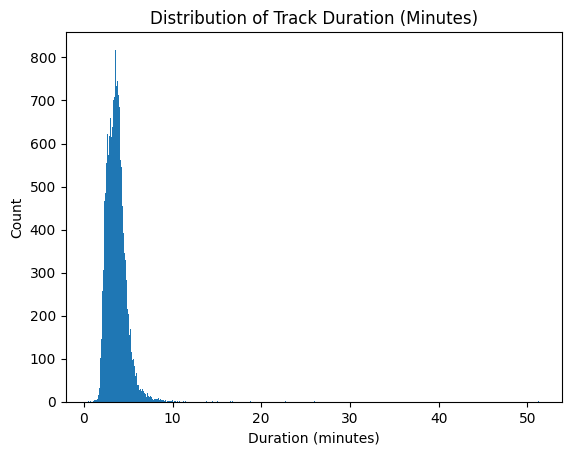

Average Song Length:  3.678070969791367


In [ ]:
#understanding song length
#convert into minutes
duration_min = df_features['spotify_track_duration_ms'] / 60000

plt.hist(duration_min, bins=700)
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.title("Distribution of Track Duration (Minutes)")
plt.show()

print("Average Song Length: ",duration_min.mean())

In [37]:
df_combined.columns

Index(['index_x', 'url', 'WeekID', 'Week Position', 'Song_x', 'Performer_x',
       'SongID', 'Instance', 'Previous Week Position', 'Peak Position',
       'Weeks on Chart', 'index_y', 'Performer_y', 'Song_y', 'spotify_genre',
       'spotify_track_id', 'spotify_track_preview_url',
       'spotify_track_duration_ms', 'spotify_track_explicit',
       'spotify_track_album', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'spotify_track_popularity'],
      dtype='str')

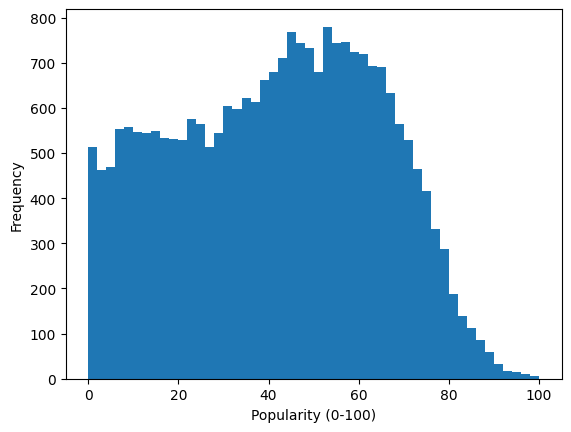

In [73]:
#understanding popularity
plt.hist(df_features['spotify_track_popularity'], bins=50)
plt.xlabel('Popularity (0-100)')
plt.ylabel('Frequency')
plt.show()

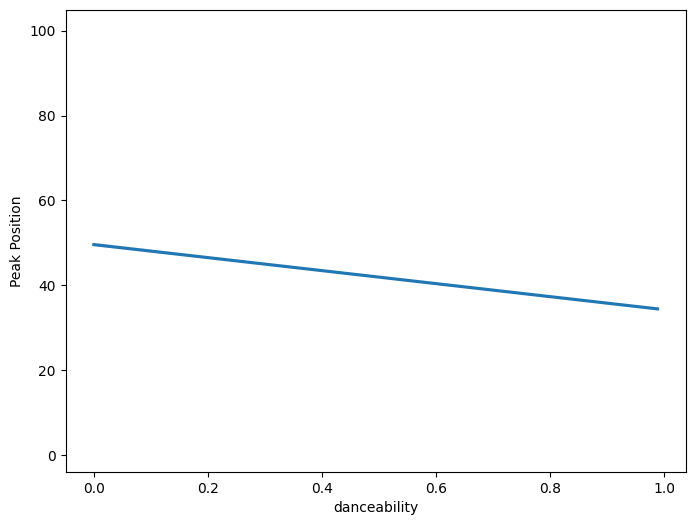

In [74]:
#understanding connection between Peak Position and features
plt.figure(figsize=(8,6))
sns.regplot(
    data=df_combined,
    x='danceability',
    y='Peak Position',
    scatter_kws={'alpha':0.001}
)

plt.show()

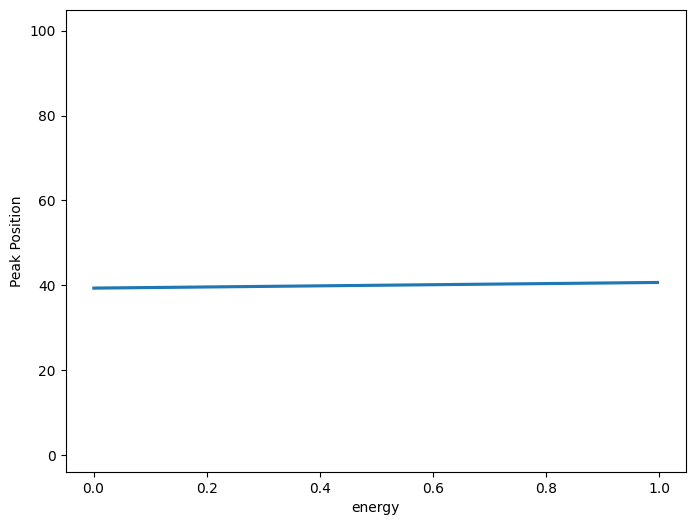

In [61]:
plt.figure(figsize=(8,6))
sns.regplot(
    data = df_combined,
    x='energy',
    y='Peak Position',
    scatter_kws={'alpha':0.001}
)

plt.show()

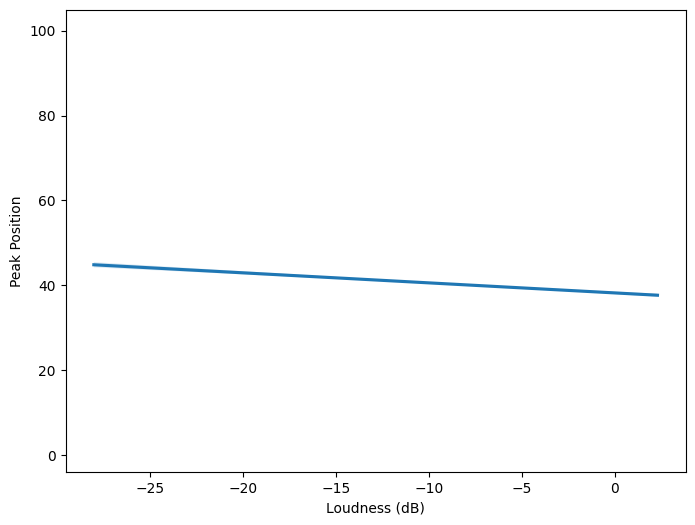

In [62]:
plt.figure(figsize=(8,6))
sns.regplot(
    data = df_combined,
    x='loudness',
    y='Peak Position',
    scatter_kws={'alpha':0.001}
)

plt.xlabel("Loudness (dB)")
plt.show()

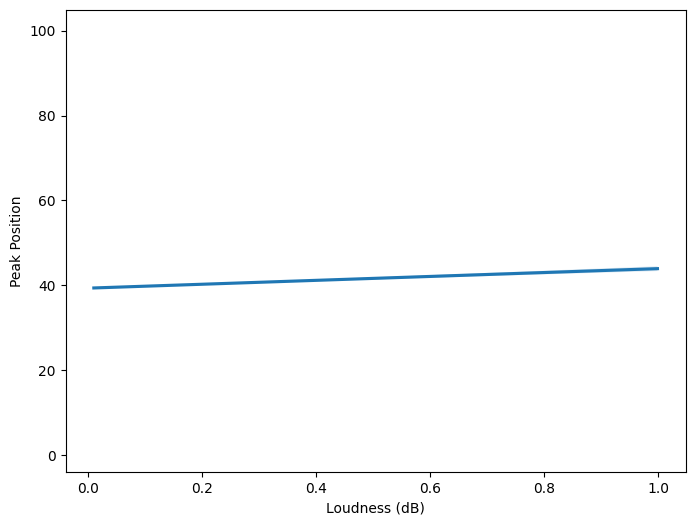

In [65]:
plt.figure(figsize=(8,6))

sns.regplot(
    data = df_combined,
    x='liveness',
    y='Peak Position',
    scatter_kws={'alpha':0.001}
)

plt.xlabel("Loudness (dB)")
plt.show()

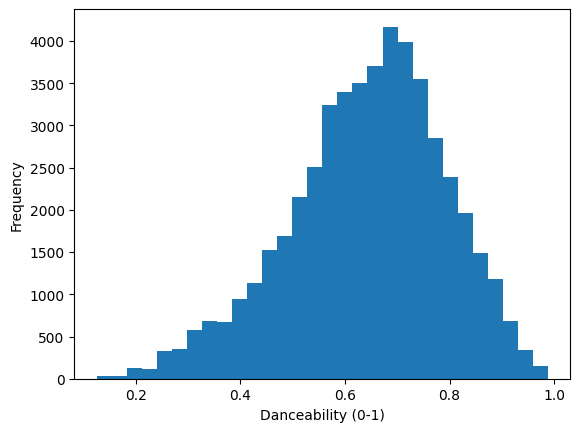

In [82]:
#understanding hit songs and their features

plt.hist(hit_songs['danceability'], bins=30)
plt.xlabel('Danceability (0-1)')
plt.ylabel('Frequency')
plt.show()

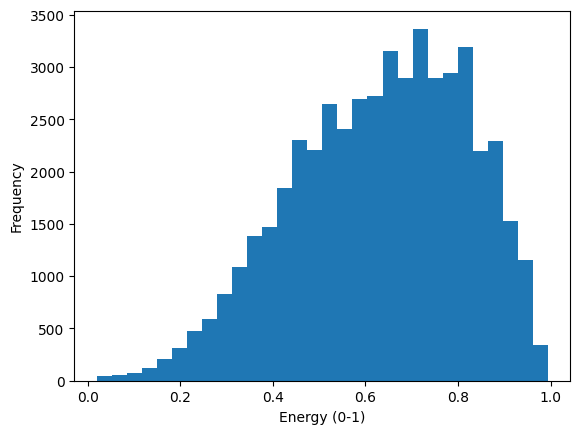

In [83]:
plt.hist(hit_songs['energy'], bins=30)
plt.xlabel('Energy (0-1)')
plt.ylabel('Frequency')
plt.show()

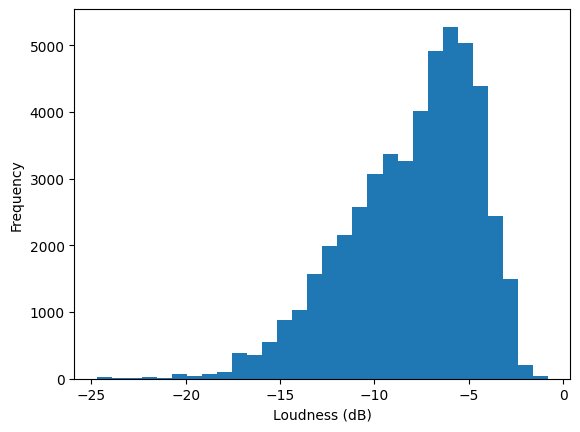

In [81]:
plt.hist(hit_songs['loudness'], bins=30)
plt.xlabel('Loudness (dB)')
plt.ylabel('Frequency')
plt.show()

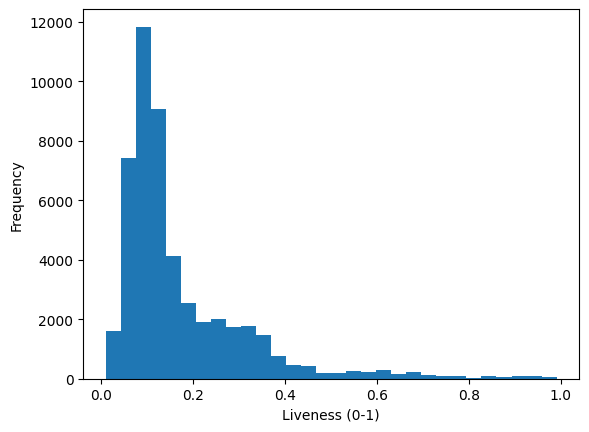

In [84]:
plt.hist(hit_songs['liveness'], bins=30)
plt.xlabel('Liveness (0-1)')
plt.ylabel('Frequency')
plt.show()